# Convolutional Neural Networks (CNNs) with PyTorch: A Hands-On Lab

Welcome to this lab! In this session, you will dive into the world of Convolutional Neural Networks (CNNs) using PyTorch. You're already familiar with building and training basic neural networks using PyTorch. Now, we'll explore how to leverage the power of CNNs for image data.

**Why CNNs?**

CNNs are particularly well-suited for image data because they can:

*   **Capture Spatial Hierarchies:** CNNs use convolutional layers to automatically learn spatial hierarchies of features from images.
*   **Reduce Parameters:** Through weight sharing and pooling, CNNs significantly reduce the number of parameters compared to fully connected networks, making them more efficient for high-dimensional image data.
*   **Translation Invariance:** CNNs can recognize patterns regardless of their location in the image, thanks to the way convolutional filters operate.

**Learning Objectives:**

By the end of this lab, you will be able to:

*   Understand the fundamental building blocks of CNNs: convolutional layers, pooling layers, and activation functions.
*   Prepare image datasets for training CNNs using PyTorch's `torchvision`.
*   Build a CNN model in PyTorch.
*   Train and evaluate a CNN model on image data.
*   Visualize model predictions and analyze failure cases.
*   Understand and implement He initialization.

**Important Notes (GPU Usage):**

*   This lab is designed to be run on a GPU for faster training. If you are using Colab, before you start, make sure to select a GPU runtime.
    *   Go to `Runtime` -> `Change runtime type`.
    *   Under `Hardware accelerator`, select `GPU`.
    *   Click `Save`. This will restart your runtime.
*   We will verify GPU use by printing the selected device.

Let's begin!

## Section 1: Setting Up PyTorch and Preparing the Data

In this section, we will set up our environment by importing the necessary libraries and preparing the image data for our CNN. We'll be using the FashionMNIST dataset, which consists of 28x28 grayscale images of clothing items in 10 classes.

### Task 1.1: Importing Libraries

Import `torch`, `torch.nn`, `torch.optim`, `torchvision`, `torchvision.transforms`, `matplotlib.pyplot`, `numpy`, and `tqdm.auto`. Set a manual seed of 42 for reproducibility. Also, add code to check and print the device being used (CPU or GPU).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


C:\Users\Immanuelle\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task 1.2: Downloading and Loading the FashionMNIST Dataset

We'll use the `torchvision` library to download and load the FashionMNIST dataset. We'll also apply some transformations to the data:

1.  **ToTensor:** Convert the images to PyTorch tensors.
2.  **Normalize:** Normalize the pixel values to the range [-1, 1]. Since FashionMNIST is grayscale, we only need one value for the mean and standard deviation.

We'll create data loaders for both the training and testing sets, using a batch size of 32 and 2 worker processes.

In [2]:
# Define transformations: ToTensor and Normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                              download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                             download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

### Task 1.3: Visualizing the Data

Let's visualize a few images from the training set to get a feel for the data.  We'll create a grid of images manually using `matplotlib.pyplot.subplots` to have more control over the layout.

1.  Get a batch of training images and their corresponding labels.
2.  Determine the number of rows and columns for the grid (e.g., 8 images per row).
3.  Create a figure and a grid of subplots using `plt.subplots()`.
4.  Iterate through the images:
    *   Unnormalize each image.
    *   Plot the image on the corresponding subplot using `ax.imshow()`.
    *   Set the label as the title of the subplot using `ax.set_title()`, ensuring the label is clearly visible on top of the image.
    *   Turn off the axes for each subplot using `ax.axis('off')`.
5.  Remove any unused subplots if the number of images is not a multiple of the number of columns.
6.  Adjust the spacing between subplots using `plt.subplots_adjust()` if needed.
7.  Display the plot using `plt.show()`.

Make sure the label for each image is clearly displayed on top of the image within the grid, and the overall layout is neat and organized.

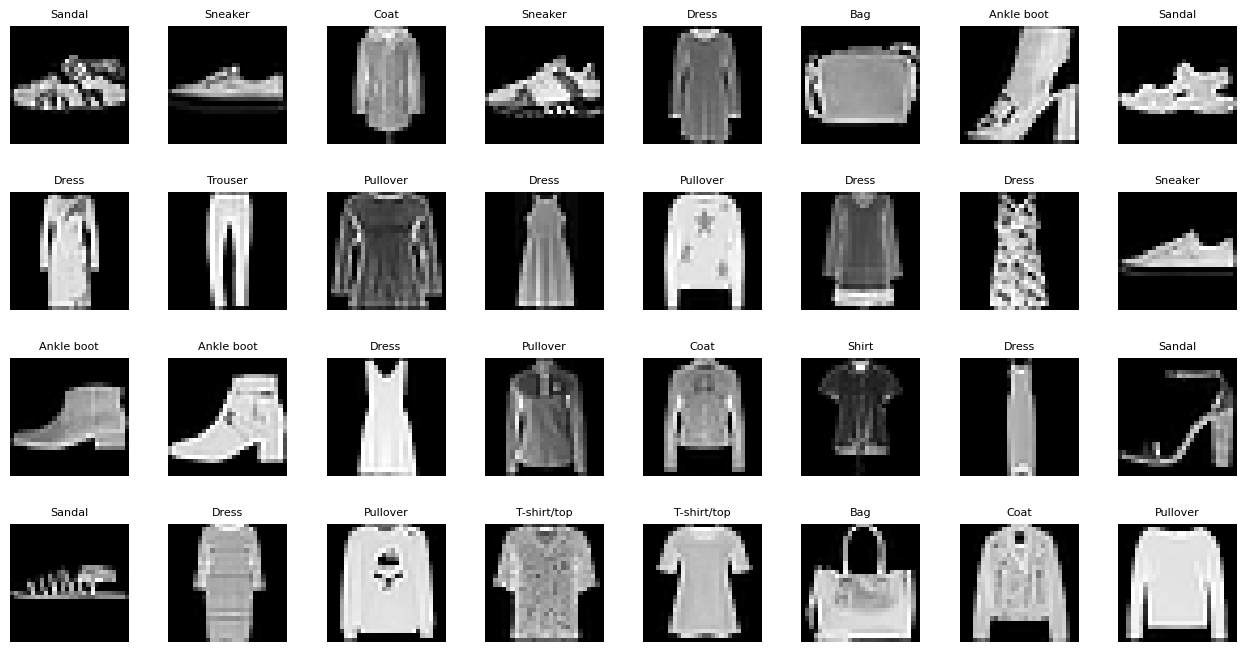

In [3]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

num_images = len(images)
cols = 8
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 2 * rows))
axes = axes.flatten()

for i in range(num_images):
    img = images[i] * 0.5 + 0.5  # Unnormalize from [-1,1] to [0,1]
    npimg = img.numpy().squeeze()
    axes[i].imshow(npimg, cmap='gray')
    axes[i].set_title(classes[labels[i]], fontsize=8)
    axes[i].axis('off')

for i in range(num_images, len(axes)):
    fig.delaxes(axes[i])

plt.subplots_adjust(hspace=0.4)
plt.show()

## Section 2: Building the Model

Here, we'll define our Convolutional Neural Network (CNN). We'll use a VGG16-*like* architecture, which is deep.  This depth is important for demonstrating the impact of initialization. We'll start with a *poor* initialization strategy to show its negative effects, then improve it later.

We will initially initialize weights with random values from a Gaussian (normal) distribution with a standard deviation of 0.1.

### Task 2.1: Define the VGG16-like CNN Class

Create a class `VGG16LikeNet` that inherits from `nn.Module`. Define the layers as described. This architecture is a simplified VGG16, adapted for FashionMNIST's 28x28 input size.

**Architecture:**

The network has several convolutional blocks followed by fully connected layers:

*   **Block 1:**
    *   Conv2d(1, 64, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(64, 64, kernel_size=3, padding=1)
    *   ReLU()
    *   MaxPool2d(kernel_size=2, stride=2)

*   **Block 2:**
    *   Conv2d(64, 128, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(128, 128, kernel_size=3, padding=1)
    *   ReLU()
    *   MaxPool2d(kernel_size=2, stride=2)

*   **Block 3:**
    *   Conv2d(128, 256, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(256, 256, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(256, 256, kernel_size=3, padding=1)
    *   ReLU()
    *   MaxPool2d(kernel_size=2, stride=2)

*   **Block 4:**
    *   Conv2d(256, 512, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(512, 512, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(512, 512, kernel_size=3, padding=1)
    *   ReLU()
    *   MaxPool2d(kernel_size=2, stride=2)  _Note: No pooling after Block 4_

*   **Block 5:**
    *   Conv2d(512, 512, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(512, 512, kernel_size=3, padding=1)
    *   ReLU()
    *   Conv2d(512, 512, kernel_size=3, padding=1)
    *   ReLU()
    *   MaxPool2d(kernel_size=2, stride=2)

*   **Fully Connected Layers:**
    *   Linear(512 \* 1 \* 1, 4096)  (Input size depends on previous layers. FashionMNIST is 28x28; five 2x2 max-pooling layers result in a 1x1 feature map. We have 512 channels.)
    *   ReLU()
    *   Linear(4096, 4096)
    *   ReLU()
    *   Linear(4096, 10)  (10 output classes)

**Important: Initialization (Poor Initialization)**

1.  **Create an `init_weights_poor` function:**
    *   Take a module `m` as input.
    *   Check `m`'s type with `isinstance`:
        *   If `m` is `nn.Conv2d` or `nn.Linear`:
            *   Initialize weights with a normal distribution (mean 0, std 0.1): `m.weight.data.normal_(0, 0.1)`
            *   Initialize bias to 0: `m.bias.data.fill_(0.0)` if `m.bias is not None`.

2.  **Apply Initialization:** After defining *all* layers in `__init__`, apply:

    ```python
    self.apply(init_weights_poor)
    ```

In [4]:
def init_weights_poor(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        m.weight.data.normal_(0, 0.1)
        if m.bias is not None:
            m.bias.data.fill_(0.0)

class VGG16LikeNet(nn.Module):
    def __init__(self):
        super(VGG16LikeNet, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 4 (No pooling after Block 4)
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, 10)
        )

        self.apply(init_weights_poor)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### Task 2.2: Instantiate the Model and Print its Architecture

Create an instance of the `VGG16LikeNet` class and call it `net`. Print the model's architecture using `print(net)`.  **Important:** Move the model to the GPU using `net = net.to(device)`.

In [5]:
net = VGG16LikeNet()
net = net.to(device)
print(net)

VGG16LikeNet(
  (block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bl

## Section 3: Training the Model (with Poor Initialization)

Now that we have our model defined (with poor initialization), we'll train it on the FashionMNIST training data. We'll see how the poor initialization affects the training process.

### Task 3.1: Define Loss Function and Optimizer

1.  Define the loss function as `nn.CrossEntropyLoss()` and call it `criterion`.
2.  Define the optimizer as `optim.Adam` with a learning rate of 0.001, and pass `net.parameters()` to it. Call the optimizer `optimizer`.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

### Task 3.2: Training Loop

Implement the training loop:

1.  Set the number of epochs to a small value initially (e.g., 5 or 10) to observe the initial training behavior.  We'll increase it later.
2.  Iterate over the training data for each epoch. Use `tqdm` to wrap the epoch loop for a progress bar.
3.  In each iteration:
    *   Get the inputs and labels from the data loader and move them to the GPU using `.to(device)`.
    *   Zero the parameter gradients using `optimizer.zero_grad()`.
    *   Perform the forward pass: `outputs = net(inputs)`.
    *   Compute the loss: `loss = criterion(outputs, labels)`.
    *   Perform the backward pass: `loss.backward()`.
    *   Update the parameters: `optimizer.step()`.
    *   Accumulate the loss.
4.  Print the average loss for each epoch.
5.  Store the training loss after each epoch in a list called `losses`.
6.  After training, plot the losses using `matplotlib`.

Training (Poor Init):  10%|██████                                                       | 1/10 [00:40<06:00, 40.09s/it]

Epoch [1/10], Loss: 81528.9607


Training (Poor Init):  20%|████████████▏                                                | 2/10 [01:21<05:25, 40.74s/it]

Epoch [2/10], Loss: 2.3271


Training (Poor Init):  30%|██████████████████▎                                          | 3/10 [02:02<04:45, 40.77s/it]

...

Epoch [8/10], Loss: 2.3044


Training (Poor Init):  90%|██████████████████████████████████████████████████████▉      | 9/10 [06:07<00:40, 40.90s/it]

Epoch [9/10], Loss: 2.3039


Training (Poor Init): 100%|████████████████████████████████████████████████████████████| 10/10 [06:48<00:00, 40.88s/it]

Epoch [10/10], Loss: 2.3036


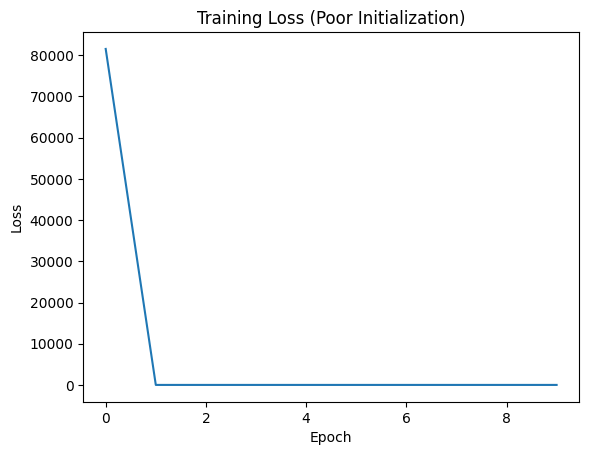

In [7]:
num_epochs = 10
losses = []

for epoch in tqdm(range(num_epochs), desc='Training (Poor Init)'):
    running_loss = 0.0
    num_batches = 0
    net.train()
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

    epoch_loss = running_loss / num_batches
    losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# Plot training losses
plt.figure()
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (Poor Initialization)')
plt.show()

## Section 4: Testing the Model (with Poor Initialization)

Now, we'll evaluate the performance of our trained model (with poor initialization) on the test set.  We expect the performance to be relatively poor due to the initialization issues we discussed.

### Task 4.1: Evaluate the Model on the Test Set

Compute the accuracy of the trained model on the entire test set.

1.  Iterate through the test data using the `testloader`.
2.  For each batch:
    *   Get the inputs and labels and move them to the GPU.
    *   Perform a forward pass to get the model's predictions: `outputs = net(inputs)`.
    *   Get the predicted class labels using `torch.max(outputs, 1)`.
    *   Update the total number of samples and the number of correctly classified samples.
3.  Calculate the overall accuracy: `accuracy = 100 * correct / total`.
4.  Print the accuracy.

In [8]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on test set (Poor Init): {accuracy:.2f}%')

Accuracy on test set (Poor Init): 10.00%


### Task 4.2: Evaluate Class-wise Accuracy

Now, let's see how the model performs on each class individually. Calculate and print the accuracy for each class.

1.  Create a list to store the number of correctly classified samples for each class `class_correct`.
2.  Create a list to store the total number of samples for each class `class_total`.
3.  Iterate over the test data.
    *   Move data to GPU.
4.  For each batch update the `class_correct` and `class_total`.
5.  Print the accuracy for each class.

In [9]:
class_correct = [0] * 10
class_total = [0] * 10

net.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    if class_total[i] > 0:
        print(f'Accuracy of {classes[i]:>12s}: {100 * class_correct[i] / class_total[i]:.2f}%')

Accuracy of  T-shirt/top: 0.00%
Accuracy of      Trouser: 0.00%
Accuracy of     Pullover: 0.00%
Accuracy of        Dress: 0.00%
Accuracy of         Coat: 0.00%
Accuracy of       Sandal: 0.00%
Accuracy of        Shirt: 0.00%
Accuracy of      Sneaker: 0.00%
Accuracy of          Bag: 100.00%
Accuracy of   Ankle boot: 0.00%


### Task 4.3: Visualizing Failure Cases

We'll visualize some of the incorrect predictions. This will help you see *which* types of images are confusing the poorly-initialized network. We can reuse and slightly modify the code of the previous visualization.

1.  Create empty lists, `wrong_images`, `wrong_labels`, and `wrong_predictions` to store the failure cases.
2.  Iterate through the test data using the `testloader`.
3.  For each batch:
    *   Get the inputs and labels and move them to the GPU using `.to(device)`.
    *   Perform a forward pass to get the model's predictions: `outputs = net(inputs)`.
    *   Get the predicted class labels using `torch.max(outputs, 1)`.
    *   Compare the predicted labels with the ground truth labels.
    *   If a prediction is incorrect, append the image, ground truth label, and predicted label to the respective lists (`wrong_images`, `wrong_labels`, `wrong_predictions`).
4.  After iterating through the entire test set, display a subset of the failure cases (e.g., the first 32) in a grid:
    *   Determine the number of rows and columns for the grid (similar to Task 1.3).
    *   Create a figure and a grid of subplots using `plt.subplots()`.
    *   Iterate through the collected failure cases (up to the maximum number you want to display):
        *   Unnormalize each image and move to CPU for display.
        *   Plot the image on the corresponding subplot using `ax.imshow()`.
        *   Create a combined label string showing both the ground truth (GT) and predicted (Pred) labels.
        *   Set the combined label as the title of the subplot using `ax.set_title()`, ensuring it's clearly visible.
        *   Turn off the axes for each subplot using `ax.axis('off')`.
    *   Remove any unused subplots.
    *   Adjust the spacing between subplots using `plt.subplots_adjust()` if needed.
    *   Display the plot using `plt.show()`.

**Hint:** You can adapt the grid layout code from Task 1.3. Focus on clearly displaying the image, the ground truth label, and the incorrect prediction for each failure case.

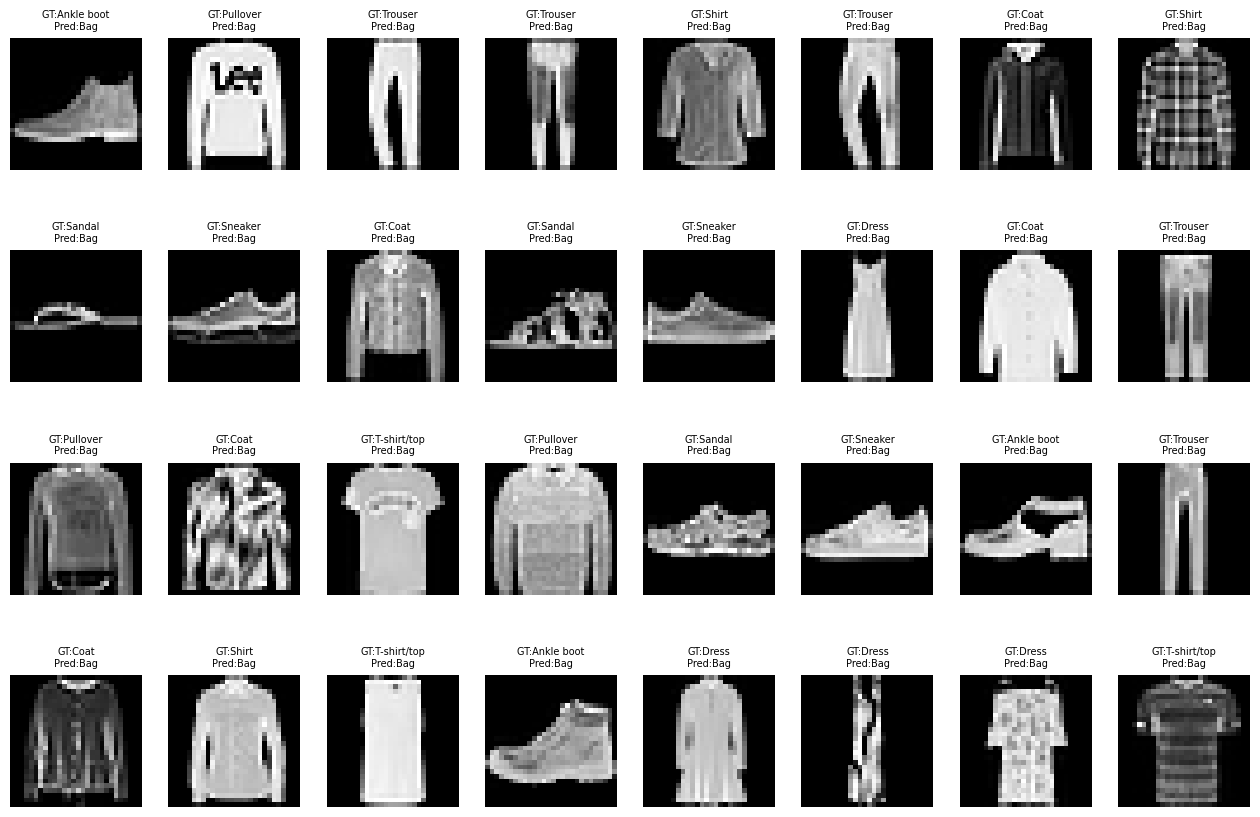

In [11]:
wrong_images = []
wrong_labels = []
wrong_predictions = []

net.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
           if predicted[i] != labels[i]:
               wrong_images.append(inputs[i].cpu())
               wrong_labels.append(labels[i].item())
               wrong_predictions.append(predicted[i].item())


num_display = min(32, len(wrong_images))
cols = 8
rows = (num_display + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 2.5 * rows))
axes = axes.flatten()

for i in range(num_display):
    img = wrong_images[i] * 0.5 + 0.5  # Unnormalize
    npimg = img.numpy().squeeze()
    axes[i].imshow(npimg, cmap='gray')
    gt = classes[wrong_labels[i]]
    pred = classes[wrong_predictions[i]]
    axes[i].set_title(f'GT:{gt}\nPred:{pred}', fontsize=7)
    axes[i].axis('off')

for i in range(num_display, len(axes)):
    fig.delaxes(axes[i])

plt.subplots_adjust(hspace=0.6)
plt.show()

## Section 5: Improving the Model with He Initialization

In previous sections, we saw the problems with poor initialization. We'll now implement **He initialization**, which is specifically designed for networks using ReLU activations, like ours.

### Task 5.1: Understanding He Initialization

**Why He Initialization with ReLUs?**

*   **Xavier Initialization:** Designed primarily for activations like *tanh*, which are symmetric around zero.
*   **ReLU Activation:**  `f(x) = max(0, x)`.  ReLU outputs only positive values (or zero).  This asymmetry means that the variance of the activations can change differently compared to *tanh*.
*   **He Initialization:**  Addresses this by adjusting the scaling factor in the standard deviation calculation.

**The Formula:**

We'll use the **normal distribution** version of He initialization:

*   Weights are drawn from a normal distribution with mean 0 and standard deviation:

    `std = sqrt(2 / fan_in)`

Where:

*   `fan_in`: Number of input units to the layer.

Notice that we only use `fan_in` (the number of input units) in the denominator, *not* `fan_in + fan_out` as in Xavier initialization.  This is the key difference. This scaling is derived by considering the variance of the output of a ReLU layer.

**Read the Paper (Optional):**

"Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification" by He et al. (2015): [https://arxiv.org/abs/1502.01852](https://arxiv.org/abs/1502.01852)

### Task 5.2: Implementing He Initialization (with an Initialization Function)

1.  **Create a New Class:** Create a new class `VGG16LikeNetHe` that inherits from `nn.Module`.

2.  **Copy Architecture:** Copy the `__init__` and `forward` methods from your original `VGG16LikeNet` class into `VGG16LikeNetHe`. *Do not* include any initialization within the `__init__` method itself (besides defining the layers).

3.  **Create an `init_weights` function:**
    *   Name the function `init_weights`.
    *   Inside `init_weights`, use `isinstance` to check the module type (`m`):
        *   **If `m` is an `nn.Conv2d` layer:**
            *   Calculate `fan_in`:  This is the number of input channels multiplied by the kernel height and width.
            *   Calculate the standard deviation (`std`): `std = sqrt(2 / fan_in)`.  **Note: Only `fan_in` is used.**
            *   Initialize the weights using `m.weight.data.normal_(0, std)`. This directly draws from a normal distribution with mean 0 and the calculated `std`.
            *   If the layer has a bias (it usually does), initialize it to zero: `m.bias.data.zero_()` if `m.bias is not None`.
        *   **If `m` is an `nn.Linear` layer:**
            *   Calculate `fan_in`: This is simply the number of input features.
            *   Calculate the standard deviation (`std`): `std = sqrt(2 / fan_in)`. **Note: Only `fan_in` is used.**
            *   Initialize the weights: `m.weight.data.normal_(0, std)`.
            *    If the layer has a bias, Initialize it to zero: `m.bias.data.zero_()` if `m.bias is not None`.
4.  **Apply Initialization:** After defining the layers inside the `__init__` method of `VGG16LikeNetHe`, apply the initialization: `self.apply(init_weights)`.

In [13]:
import math

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        fan_in = m.in_channels * m.kernel_size[0] * m.kernel_size[1]
        std = math.sqrt(2.0 / fan_in)
        m.weight.data.normal_(0, std)
        if m.bias is not None:
            m.bias.data.zero_()
    elif isinstance(m, nn.Linear):
        fan_in = m.in_features
        std = math.sqrt(2.0 / fan_in)
        m.weight.data.normal_(0, std)
        if m.bias is not None:
            m.bias.data.zero_()

class VGG16LikeNetHe(nn.Module):
    def __init__(self):
        super(VGG16LikeNetHe, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 4 (No pooling after Block 4)
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, 10)
        )

        # Apply He initialization
        self.apply(init_weights)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### Task 5.3: Instantiate, Train, and Evaluate

Instantiate, train, and evaluate the model with He initialization.

1.  **Instantiate:** `net_he = VGG16LikeNetHe()`. Move it to the GPU.

2.  **Train:** Use the training loop from Section 3.2 (with `net_he`, a new optimizer `optimizer_he`, and a new loss list `losses_he`).

3.  **Evaluate:** Use the evaluation code from Sections 4.1 and 4.2 (with `net_he`).

In [14]:
torch.manual_seed(42)
net_he = VGG16LikeNetHe()
net_he = net_he.to(device)


criterion_he = nn.CrossEntropyLoss()
optimizer_he = optim.Adam(net_he.parameters(), lr=0.001)


num_epochs = 10
losses_he = []

for epoch in tqdm(range(num_epochs), desc='Training (He Init)'):
    running_loss = 0.0
    num_batches = 0
    net_he.train()
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_he.zero_grad()
        outputs = net_he(inputs)
        loss = criterion_he(outputs, labels)
        loss.backward()
        optimizer_he.step()

        running_loss += loss.item()
        num_batches += 1

    epoch_loss = running_loss / num_batches
    losses_he.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')


#starting the evaluation

correct = 0
total = 0

net_he.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net_he(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on test set (He Init): {accuracy:.2f}%')


class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net_he(inputs)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    if class_total[i] > 0:
        print(f'Accuracy of {classes[i]:>12s}: {100 * class_correct[i] / class_total[i]:.2f}%')

Training (He Init):  10%|██████▎                                                        | 1/10 [00:41<06:11, 41.27s/it]

Epoch [1/10], Loss: 0.9000


Training (He Init):  20%|████████████▌                                                  | 2/10 [01:22<05:29, 41.17s/it]

Epoch [2/10], Loss: 0.4271


Training (He Init):  30%|██████████████████▉                                            | 3/10 [02:03<04:48, 41.22s/it]

...

Training (He Init):  90%|████████████████████████████████████████████████████████▋      | 9/10 [06:11<00:41, 41.32s/it]

Epoch [9/10], Loss: 0.2620


Training (He Init): 100%|██████████████████████████████████████████████████████████████| 10/10 [06:53<00:00, 41.34s/it]

Epoch [10/10], Loss: 0.2364


Accuracy on test set (He Init): 91.46%
Accuracy of  T-shirt/top: 86.30%
Accuracy of      Trouser: 97.90%
Accuracy of     Pullover: 86.00%
Accuracy of        Dress: 93.00%
Accuracy of         Coat: 88.30%
Accuracy of       Sandal: 99.00%
Accuracy of        Shirt: 73.00%
Accuracy of      Sneaker: 97.00%
Accuracy of          Bag: 98.40%
Accuracy of   Ankle boot: 95.70%


### Task 5.4: Comparison Plots

Compare the training losses of the poorly initialized model and the He-initialized model. Hint: take the log of the losses since the scale difference is likely big.

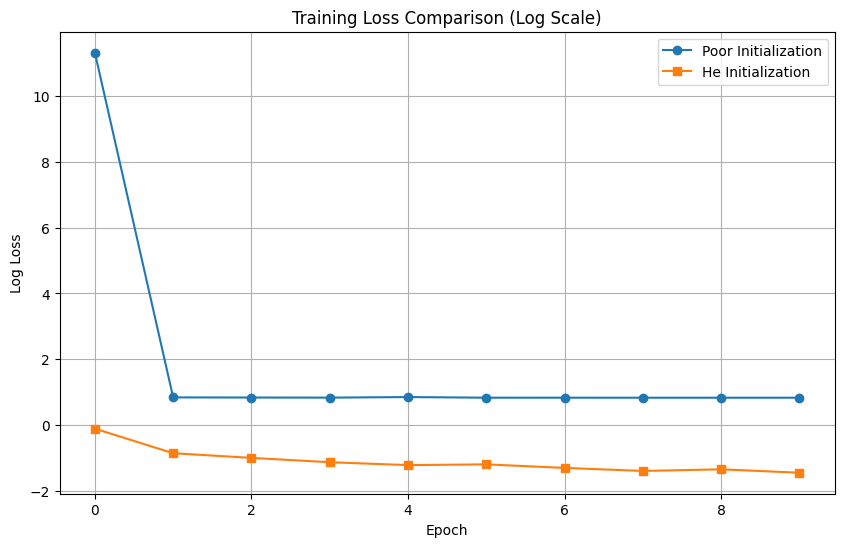

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(np.log(losses), label='Poor Initialization', marker='o')
plt.plot(np.log(losses_he), label='He Initialization', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Training Loss Comparison (Log Scale)')
plt.legend()
plt.grid(True)
plt.show()